# Personal Research Agent v4 — End-to-End Notebook

![V4](https://img.shields.io/badge/version-v4-blue) ![E2E](https://img.shields.io/badge/flow-end--to--end-success) ![Notebook](https://img.shields.io/badge/artifact-jupyter-orange)

This notebook follows the same teaching style used in Module 4: clear phases, visible graph flow, parallel retrieval evidence, and reproducible checks.

## What this notebook simulates end-to-end
- Environment and key loading (`.env` first, secure prompt fallback)
- Architecture and graph rendering
- User profile + memory intake
- Full fixture run + bounded web/live smoke
- Parallel fan-out evidence from debug artifacts
- Generic item drill-down simulation (`/detail` + natural language)
- Observability via `kb_logs/` and DB logs


In [1]:
%pip install -q -U langgraph langgraph-prebuilt langgraph-sdk langgraph-checkpoint-sqlite python-dotenv pandas matplotlib ipykernel nbformat notebook


Note: you may need to restart the kernel to use updated packages.


## Setup and Secrets

We load `.env` from the v4 project root. If a key is missing, we ask securely with `getpass`.

Keys checked:
- `GOOGLE_API_KEY`
- `OPENROUTER_API_KEY`
- `OPENAI_API_KEY`
- `TAVILY_API_KEY`
- `LANGSMITH_API_KEY` (optional tracing)


In [2]:
import json
import os
import sys
import getpass
from pathlib import Path

from dotenv import load_dotenv

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "app").exists() and (candidate / "scripts").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing app/ and scripts/")

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

env_path = PROJECT_ROOT / ".env"
load_dotenv(env_path)

def _set_env(var: str, prompt_if_missing: bool = True) -> str:
    current = os.environ.get(var, "").strip()
    if current:
        return "env"
    if not prompt_if_missing:
        return "missing"
    value = getpass.getpass(f"{var} (leave empty to skip): ").strip()
    if value:
        os.environ[var] = value
        return "prompt"
    return "missing"

KEYS = [
    "GOOGLE_API_KEY",
    "OPENROUTER_API_KEY",
    "OPENAI_API_KEY",
    "TAVILY_API_KEY",
    "LANGSMITH_API_KEY",
]

key_status = {key: _set_env(key, prompt_if_missing=True) for key in KEYS}
print("project_root=", PROJECT_ROOT)
print("env_file=", env_path if env_path.exists() else "(missing)")
print("key_status=", key_status)

# Optional tracing flags (enabled only when LANGSMITH_API_KEY is present).
if os.environ.get("LANGSMITH_API_KEY", "").strip():
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ.setdefault("LANGSMITH_PROJECT", "personal-research-agent-v4-e2e")
    print("LangSmith tracing enabled")
else:
    print("LangSmith tracing not enabled (missing LANGSMITH_API_KEY)")


project_root= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4
env_file= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/.env
key_status= {'GOOGLE_API_KEY': 'env', 'OPENROUTER_API_KEY': 'env', 'OPENAI_API_KEY': 'env', 'TAVILY_API_KEY': 'env', 'LANGSMITH_API_KEY': 'env'}
LangSmith tracing enabled


## Architecture and Graph Visualization

Main components used in this simulation:
- `app/main.py`: high-level run orchestration and detailed result contract
- `app/pipeline.py`: retrieval, validation, scoring, interpretation, output artifacts
- `app/graphs/research_graph.py`: LangGraph entrypoint
- `app/db.py`: persistence layer (SQLite/Postgres backend abstraction)
- `app/tools/telegram_bot.py`: command handlers and generic item drill-down logic


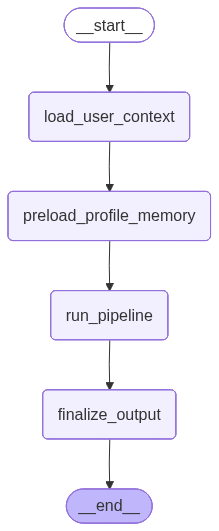

In [3]:
from IPython.display import Image, Markdown, display

from app.graphs.research_graph import graph

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("PNG graph rendering unavailable:", exc)
    try:
        mermaid = graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))
    except Exception as fallback_exc:
        print("Mermaid fallback unavailable:", fallback_exc)


## Phase A — Profile and Intake Simulation

This phase initializes runtime storage, ensures a test user, and demonstrates profile + memory writes before the run.


In [4]:
from app import config as app_config
from app import db
from app import db_users
from app import pipeline

config = app_config.load_app_config()
db.initialize_database(config.runtime_db_path)
db_users.seed_users_from_config(db_path=config.runtime_db_path)

chat_id = 100000001
user = db_users.ensure_user(chat_id=chat_id, db_path=config.runtime_db_path)

# Intake-style updates (generic and reusable).
profile = db.upsert_profile(
    user_id=int(user["id"]),
    language=str(user.get("language") or config.default_language),
    home_location="Maastricht",
    desired_depth="standard",
    db_path=config.runtime_db_path,
)
db.upsert_profile_fact(
    user_id=int(user["id"]),
    fact_key="home_location",
    fact_value={"value": "Maastricht"},
    source="notebook_e2e",
    is_explicit=True,
    db_path=config.runtime_db_path,
)
db.set_topic_weight(
    user_id=int(user["id"]),
    topic="bitcoin",
    subtopic="market",
    weight=1.0,
    enabled=True,
    source="notebook_e2e",
    db_path=config.runtime_db_path,
)

temporary_contexts = db.list_active_temporary_contexts(user_id=int(user["id"]), db_path=config.runtime_db_path)
topic_plan = pipeline.build_topic_plan(
    user_id=int(user["id"]),
    topics=pipeline.normalize_topics_for_run(user.get("topics")),
    db_path=config.runtime_db_path,
)

print("db_backend=", config.db_backend)
print("runtime_db=", config.database_url if config.db_backend == "postgres" else config.db_path)
print("user=", {"id": user["id"], "name": user["name"], "language": user["language"], "topics": user["topics"]})
print("profile_version=", profile.get("profile_version"))
print("temporary_context_count=", len(temporary_contexts))
print("topic_plan=", topic_plan)


db_backend= sqlite
runtime_db= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/db/personal_research_agent.sqlite
user= {'id': 1, 'name': 'Example Italian Tester', 'language': 'it', 'topics': ['news', 'events', 'bitcoin']}
profile_version= 2
temporary_context_count= 0
topic_plan= {'news': ['safety', 'economy', 'infrastructure'], 'events': ['local-calendar', 'family', 'culture'], 'bitcoin': ['market', 'core-dev', 'onchain']}


## Phase B — End-to-End Fixture Run

Run the full pipeline deterministically in fixture mode and inspect output contracts.


In [5]:
from app import main as agent_main

fixture_result = agent_main.run_for_chat_detailed(
    chat_id=chat_id,
    mode="fixture",
    max_results_per_query=1,
    fallback_to_stub=False,
)

summary_view = {
    "run_id": fixture_result.get("run_id"),
    "mode": fixture_result.get("mode"),
    "quality": fixture_result.get("summary", "")[:120],
    "selected_counts": fixture_result.get("selected_counts"),
    "debug_dir": fixture_result.get("debug_dir"),
}
summary_view


{'run_id': 29,
 'mode': 'fixture',
 'quality': 'Digest Personal Research Agent v4 completato (run_id=29, quality=warn, mode=fixture). Selezionati: news=0, events=1, bit',
 'selected_counts': {'news': 0, 'events': 1, 'bitcoin': 1},
 'debug_dir': '/home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155300Z__v4-29'}

In [6]:
from pathlib import Path

report_path = Path(str(fixture_result.get("report_path") or ""))
newsletter_path = Path(str(fixture_result.get("newsletter_path") or ""))
debug_dir = Path(str(fixture_result.get("debug_dir") or ""))

print("report_path=", report_path)
print("newsletter_path=", newsletter_path)
print("debug_dir=", debug_dir)

report_excerpt = report_path.read_text(encoding="utf-8")[:1200] if report_path.exists() else "(missing report)"
newsletter_excerpt = newsletter_path.read_text(encoding="utf-8")[:1200] if newsletter_path.exists() else "(missing newsletter)"

print("\n--- REPORT EXCERPT ---\n")
print(report_excerpt)
print("\n--- NEWSLETTER EXCERPT ---\n")
print(newsletter_excerpt)


report_path= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155300Z__v4-29/report.md
newsletter_path= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155300Z__v4-29/newsletter.md
debug_dir= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155300Z__v4-29

--- REPORT EXCERPT ---

# Report Personal Research Agent v4

User: Example Italian Tester | Language: it | Quality: warn
Conteggi selezionati: news=0, events=1, bitcoin=1

## Elementi selezionati

### Notizie
- Nessun elemento selezionato in questa run.

### Eventi
- [Family science weekend in Maastricht](https://example.com/events/2026-04-25-family-science-maastricht)
  - Fonte: example.com | Score: 1.23
  - Perché selezionato: matched events query from example.com
  - Cosa è successo: Il weekend della scienza per famiglie si terrà a Maastricht il 25 e 26 aprile 2026. L'evento è pe

## Phase C — Bounded Web/Live Smoke

Runs remain bounded (`max_results_per_query=1`).
- If live key(s) are missing, we skip gracefully.
- Notebook remains usable without live credentials.


In [7]:
def bounded_smoke(mode: str) -> dict:
    try:
        return agent_main.run_for_chat_detailed(
            chat_id=chat_id,
            mode=mode,
            max_results_per_query=1,
            fallback_to_stub=False,
        )
    except Exception as exc:
        return {"error": str(exc), "mode": mode}

web_result = bounded_smoke("web_fallback")
print("web_fallback summary:", web_result.get("summary", web_result.get("error")))

if os.environ.get("TAVILY_API_KEY", "").strip():
    live_result = bounded_smoke("live")
    print("live summary:", live_result.get("summary", live_result.get("error")))
else:
    print("live skipped: missing TAVILY_API_KEY")


web_fallback summary: Digest Personal Research Agent v4 completato (run_id=30, quality=warn, mode=web_fallback). Selezionati: news=2, events=0, bitcoin=2. Report: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155303Z__v4-30/report.md. Newsletter: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155303Z__v4-30/newsletter.md. Debug: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155303Z__v4-30
live summary: Digest Personal Research Agent v4 completato (run_id=31, quality=warn, mode=web_fallback). Selezionati: news=2, events=0, bitcoin=2. Report: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155311Z__v4-31/report.md. Newsletter: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155311Z__v4-31/newsletter.md. Debug: /home/roberto/wor

## Phase D — Parallel Work Evidence

Load the latest debug artifact set and inspect fan-out query generation plus retrieval/validation traces.


In [8]:
import pandas as pd

def latest_debug_dir(root: Path) -> Path:
    candidates = sorted(root.glob("*__v4-*"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise RuntimeError("No debug directories found")
    return candidates[0]

debug_root = PROJECT_ROOT / "debug"
target_debug = Path(str(fixture_result.get("debug_dir") or "")).resolve() if fixture_result.get("debug_dir") else latest_debug_dir(debug_root)
if not target_debug.exists():
    target_debug = latest_debug_dir(debug_root)

print("target_debug=", target_debug)

input_json = json.loads((target_debug / "01_input.json").read_text(encoding="utf-8")) if (target_debug / "01_input.json").exists() else {}
retrieval_json = json.loads((target_debug / "02_retrieval.json").read_text(encoding="utf-8")) if (target_debug / "02_retrieval.json").exists() else {}
validator_json = json.loads((target_debug / "02_validator.json").read_text(encoding="utf-8")) if (target_debug / "02_validator.json").exists() else {}

queries = ((input_json.get("payload") or {}).get("queries") or [])
candidates = ((retrieval_json.get("payload") or {}).get("candidate_preview") or [])
reason_counts = ((validator_json.get("payload") or {}).get("reason_counts") or {})
selected_preview = ((validator_json.get("payload") or {}).get("validated_preview") or [])

query_df = pd.DataFrame(queries)
candidate_df = pd.DataFrame(candidates)
selected_df = pd.DataFrame(selected_preview)

display(query_df.head(12))
display(candidate_df[[c for c in ["track_type", "retrieval_provider", "source", "title", "url"] if c in candidate_df.columns]].head(12))
display(selected_df[[c for c in ["track_type", "source", "quality_score", "title"] if c in selected_df.columns]].head(12))
print("reason_counts=", reason_counts)


target_debug= /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v4/debug/20260423T155300Z__v4-29


,query,subtopics,track_type
0,site:nltimes.nl Maastricht Limburg latest news...,"[safety, economy, infrastructure]",news
1,site:dutchnews.nl Maastricht Limburg latest ne...,"[safety, economy, infrastructure]",news
2,Netherlands Limburg Maastricht breaking news M...,"[safety, economy, infrastructure]",news
3,site:visitmaastricht.com Maastricht events 202...,"[local-calendar, family, culture]",events
4,site:mecc.nl Maastricht events 2026 Maastricht,"[local-calendar, family, culture]",events
5,Maastricht events this weekend date location M...,"[local-calendar, family, culture]",events
6,Bitcoin notizie oggi prezzo ETF regolamentazio...,"[market, core-dev, onchain]",bitcoin
7,Bitcoin Core aggiornamenti tecnici BIP Lightni...,"[market, core-dev, onchain]",bitcoin
8,site:bitcoinops.org/en/newsletters/ Bitcoin Op...,"[market, core-dev, onchain]",bitcoin


,track_type,retrieval_provider,source,title,url
0,news,fixture,example.com,Limburg mobility plan gets fresh funding,https://example.com/2026/04/22/limburg-mobilit...
1,events,fixture,example.com,Family science weekend in Maastricht,https://example.com/events/2026-04-25-family-s...
2,bitcoin,fixture,github.com,Bitcoin Core release candidate testing continues,https://github.com/bitcoin/bitcoin/issues/33368


,track_type,source,quality_score,title
0,events,example.com,1.23,Family science weekend in Maastricht
1,bitcoin,github.com,1.75,Bitcoin Core release candidate testing continues


reason_counts= {'not_article_page': 1}


```mermaid
graph TD
R[Run]
R --> Q1[news #1]
R --> Q2[news #2]
R --> Q3[news #3]
R --> Q4[events #4]
R --> Q5[events #5]
R --> Q6[events #6]
R --> Q7[bitcoin #7]
R --> Q8[bitcoin #8]
R --> Q9[bitcoin #9]
```

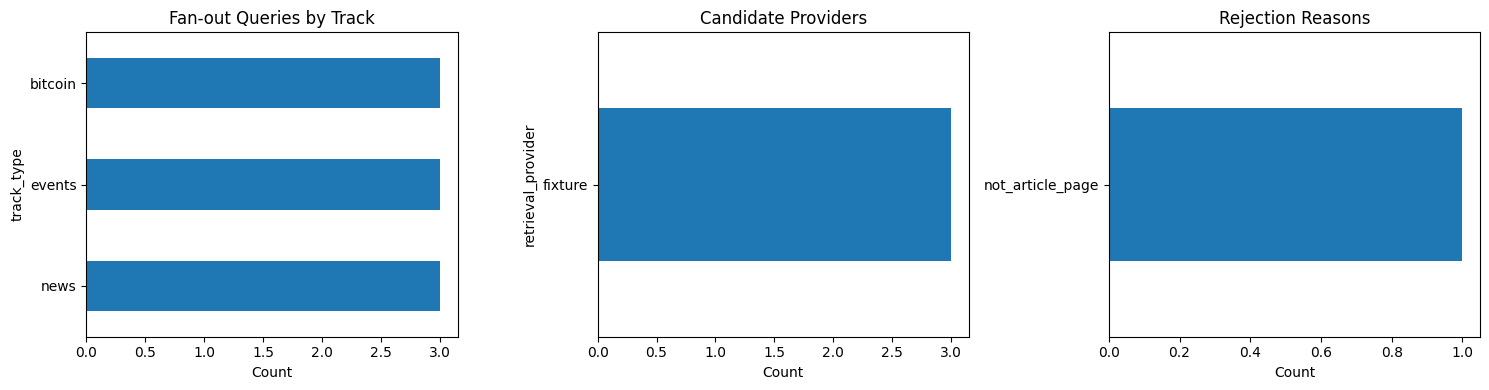

In [9]:
import matplotlib.pyplot as plt

provider_series = pd.Series(dtype="int64")
track_series = pd.Series(dtype="int64")
if not candidate_df.empty and "retrieval_provider" in candidate_df.columns:
    provider_series = candidate_df["retrieval_provider"].fillna("unknown").value_counts()
if not query_df.empty and "track_type" in query_df.columns:
    track_series = query_df["track_type"].fillna("unknown").value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
if len(track_series):
    track_series.sort_values().plot(kind="barh", ax=axes[0], title="Fan-out Queries by Track")
else:
    axes[0].set_title("Fan-out Queries by Track")
    axes[0].text(0.5, 0.5, "No data", ha="center")

if len(provider_series):
    provider_series.sort_values().plot(kind="barh", ax=axes[1], title="Candidate Providers")
else:
    axes[1].set_title("Candidate Providers")
    axes[1].text(0.5, 0.5, "No data", ha="center")

reason_series = pd.Series(reason_counts)
if len(reason_series):
    reason_series.sort_values().plot(kind="barh", ax=axes[2], title="Rejection Reasons")
else:
    axes[2].set_title("Rejection Reasons")
    axes[2].text(0.5, 0.5, "No rejections", ha="center")

for ax in axes:
    ax.set_xlabel("Count")
plt.tight_layout()

# Mermaid fan-out rendering (parallel retrieval intent view).
if len(query_df):
    lines = ["graph TD", "R[Run]"]
    for idx, row in query_df.reset_index(drop=True).iterrows():
        track = str(row.get("track_type", "topic"))
        lines.append(f"R --> Q{idx+1}[{track} #{idx+1}]")
    fanout_mermaid = "\n".join(lines)
    display(Markdown(f"```mermaid\n{fanout_mermaid}\n```"))


## Phase E — Generic Detail Request Simulation

Simulate both index-based and natural-language item references using the same generic helpers used by Telegram handlers.


In [10]:
from app.tools import telegram_bot as tg_bot

enriched_items = fixture_result.get("enriched_items") or []
projected_items = [
    tg_bot._project_item_for_reference(item, index)
    for index, item in enumerate(enriched_items[:5], start=1)
]

test_queries = [
    "dammi piu informazioni sull'evento 1",
    "more details about item 2",
    "spiega la notizia sulla causa legale",
    "details about bitcoin update",
    "thanks",
]

rows = []
for query in test_queries:
    idx = tg_bot._resolve_item_reference(query, projected_items)
    llm_used = False
    if idx is None and tg_bot._looks_like_drilldown_request(query):
        idx = tg_bot._resolve_item_reference_llm(query, projected_items)
        llm_used = idx is not None
    selected_title = ""
    if idx is not None:
        selected = next((item for item in projected_items if int(item.get("index") or 0) == idx), None)
        selected_title = str(selected.get("title") if selected else "")
    rows.append({
        "query": query,
        "looks_like_drilldown": tg_bot._looks_like_drilldown_request(query),
        "resolved_index": idx,
        "llm_fallback_used": llm_used,
        "selected_title": selected_title,
    })

detail_df = pd.DataFrame(rows)
display(detail_df)

resolved = detail_df[detail_df["resolved_index"].notna()]
if len(resolved):
    first_idx = int(resolved.iloc[0]["resolved_index"])
    first_item = next((item for item in projected_items if int(item.get("index") or 0) == first_idx), None)
    if first_item:
        print(tg_bot._format_detail_response(first_item, str(fixture_result.get("language") or "en")))


,query,looks_like_drilldown,resolved_index,llm_fallback_used,selected_title
0,dammi piu informazioni sull'evento 1,True,1.0,False,Family science weekend in Maastricht
1,more details about item 2,True,2.0,False,Bitcoin Core release candidate testing continues
2,spiega la notizia sulla causa legale,True,NaN,False,
3,details about bitcoin update,False,NaN,False,
4,thanks,False,NaN,False,


Dettaglio item 1
Family science weekend in Maastricht
- Tipo: events
- Fonte: example.com
- Sintesi: Il weekend della scienza per famiglie si terrà a Maastricht il 25 e 26 aprile 2026. L'evento è pensato per coinvolgere tutta la famiglia in attività scientifiche.
- Approfondimento: A near-term family friendly event in Maastricht with explicit date and location.
- Perché conta: Offre un'opportunità unica per le famiglie di esplorare la scienza in modo interattivo e divertente, promuovendo l'interesse per le materie STEM fin da giovani.
- Azione suggerita: Verifica il programma completo e acquista i biglietti sul sito ufficiale.
- Link: https://example.com/events/2026-04-25-family-science-maastricht


## Phase F — Observability and KB Logs

Inspect durable evidence (`kb_logs`) and recent DB execution/workflow logs.


In [11]:
kb_dir = PROJECT_ROOT / "kb_logs"
kb_files = sorted(kb_dir.glob("*.json"), key=lambda p: p.stat().st_mtime, reverse=True)
print("kb_log_count=", len(kb_files))

if kb_files:
    latest_kb = kb_files[0]
    kb_payload = json.loads(latest_kb.read_text(encoding="utf-8"))
    print("latest_kb=", latest_kb.name)
    print("kb_keys=", sorted(kb_payload.keys()))
    trace = kb_payload.get("trace_payload") if isinstance(kb_payload, dict) else None
    if isinstance(trace, dict):
        print("trace_keys=", sorted(trace.keys()))

execution_logs = db.list_execution_logs(user_id=int(user["id"]), limit=10, db_path=config.runtime_db_path)
workflow_logs = db.list_workflow_logs(user_id=int(user["id"]), limit=10, db_path=config.runtime_db_path)

display(pd.DataFrame(execution_logs))
display(pd.DataFrame(workflow_logs))


kb_log_count= 28
latest_kb= 20260423T155314Z__v4-31.json
kb_keys= ['cost_trace', 'created_at', 'mode', 'personalization', 'quality_flags', 'quality_status', 'retrieval_trace', 'run_id', 'selected_counts']


,id,user_id,run_id,stage,status,message,payload,created_at
0,60,1,31,pipeline_complete,ok,run_completed,"{'quality': 'warn', 'selected_counts': {'bitco...",2026-04-23T15:53:14+00:00
1,59,1,31,pipeline_start,ok,run_started,"{'location': 'Maastricht', 'mode': 'live', 'to...",2026-04-23T15:53:11+00:00
2,58,1,30,pipeline_complete,ok,run_completed,"{'quality': 'warn', 'selected_counts': {'bitco...",2026-04-23T15:53:11+00:00
3,57,1,30,pipeline_start,ok,run_started,"{'location': 'Maastricht', 'mode': 'web_fallba...",2026-04-23T15:53:03+00:00
4,56,1,29,pipeline_complete,ok,run_completed,"{'quality': 'warn', 'selected_counts': {'bitco...",2026-04-23T15:53:02+00:00
5,55,1,29,pipeline_start,ok,run_started,"{'location': 'Maastricht', 'mode': 'fixture', ...",2026-04-23T15:53:00+00:00
6,54,1,28,pipeline_complete,ok,run_completed,"{'quality': 'warn', 'selected_counts': {'bitco...",2026-04-23T15:27:13+00:00
7,53,1,28,pipeline_start,ok,run_started,"{'location': 'Maastricht', 'mode': 'web_fallba...",2026-04-23T15:27:04+00:00
8,52,1,27,pipeline_complete,ok,run_completed,"{'quality': 'warn', 'selected_counts': {'bitco...",2026-04-23T15:26:30+00:00
9,51,1,27,pipeline_start,ok,run_started,"{'location': 'Maastricht', 'mode': 'web_fallba...",2026-04-23T15:26:24+00:00


,id,user_id,run_id,workflow_name,step,status,payload,created_at
0,28,1,31,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:53:14+00:00
1,27,1,30,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:53:11+00:00
2,26,1,29,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:53:02+00:00
3,25,1,28,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:27:13+00:00
4,24,1,27,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:26:30+00:00
5,23,1,26,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T15:25:51+00:00
6,22,1,25,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T12:25:36+00:00
7,21,1,24,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T12:25:29+00:00
8,20,1,23,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T12:25:01+00:00
9,19,1,22,selection,feedback_and_source_adjustment,ok,{'feedback_trace': {'adjustments_preview': [{'...,2026-04-23T12:24:15+00:00


## Conclusion and Next Checks

This notebook provides a complete v4 simulation path in the same clarity style as Module 4:
- architecture and graph visibility
- reproducible fixture run
- bounded live smoke behavior
- parallel retrieval evidence
- generic item-detail interaction simulation
- observability via KB + DB logs

Suggested next checks:
1. Run this notebook with your real `.env` keys and compare quality across fixture/web/live.
2. Extend Phase E with multilingual user phrasings and verify generic match behavior.
3. Compare two consecutive runs to validate stability of selected/rejected distributions.
